<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Experiments/experiments_PDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# All needed imports
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt



In [2]:
# Original File with All featuers
source_path="/content/PDF_All_features.csv"
source_file=pd.read_csv(source_path)
source_file.head()

,file_path,file_size,title_chars,encrypted,metadata_size,page_count,valid_pdf_header,image_count,text_length,object_count,...,acroform_count,xfa_count,jbig2decode_count,colors_count,richmedia_count,trailer_count,startxref_count,has_multiple_behavioral_keywords_in_one_object,used_ocr,label
0,/content/drive/MyDrive/UNB/Mastercard project/...,20362,8,0,254,5,1,0,8018,120,...,0,0,0,0,0,0,0,0,0,0
1,/content/drive/MyDrive/UNB/Mastercard project/...,28848,35,0,242,4,1,0,11568,36,...,0,0,0,0,0,0,0,0,0,0
2,/content/drive/MyDrive/UNB/Mastercard project/...,76563,12,0,138,1,1,1,1377,21,...,0,0,0,0,0,0,0,0,1,0
3,/content/drive/MyDrive/UNB/Mastercard project/...,67982,8,0,278,4,1,0,30607,46,...,1,0,0,0,0,0,0,0,0,0
4,/content/drive/MyDrive/UNB/Mastercard project/...,3997,37,0,156,1,1,0,1,10,...,0,0,0,0,0,0,0,1,1,1


In [3]:
# Columns names
print(source_file.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['file_path', 'file_size', 'title_chars', 'encrypted', 'metadata_size',
       'page_count', 'valid_pdf_header', 'image_count', 'text_length',
       'object_count', 'font_object_count', 'embedded_file_count',
       'average_embedded_file_size', 'stream_count', 'endstream_count',
       'average_stream_size', 'entropy_of_streams', 'xref_count',
       'xref_entries', 'name_obfuscations', 'total_filters',
       'nested_filter_objects', 'objstm_count', 'js_count', 'javascript_count',
       'uri_count', 'uses_nonstandard_port', 'action_count', 'aa_count',
       'openaction_count', 'launch_count', 'submitform_count',
       'acroform_count', 'xfa_count', 'jbig2decode_count', 'colors_count',
       'richmedia_count', 'trailer_count', 'startxref_count',
       'has_multiple_behavioral_keywords_in_one_object', 'used_ocr', 'label'],
      dtype='object')>


In [4]:
# Find all zero columns

zero_columns=source_file.columns[(source_file==0).all()]
print(zero_columns)

Index(['embedded_file_count', 'average_embedded_file_size', 'xref_count',
       'xref_entries', 'submitform_count', 'jbig2decode_count',
       'trailer_count', 'startxref_count'],
      dtype='object')


In [5]:
from sklearn.model_selection import train_test_split

# Raw Features
X_raw = source_file.drop(columns=['label']).select_dtypes(include='number')
y_raw = source_file["label"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.3,
    random_state=42,
    stratify=y_raw
)

In [6]:
# Deleting zero columns

source_file=source_file.drop(columns=zero_columns)

In [7]:
source_file.describe().T

,count,mean,std,min,25%,50%,75%,max
file_size,19296.0,71308.369818,418699.216515,24.0,9620.0,17462.000000,77876.500000,3.677767e+07
title_chars,19296.0,14.792548,19.411976,0.0,0.0,8.000000,25.000000,2.890000e+02
encrypted,19296.0,0.004353,0.065837,0.0,0.0,0.000000,0.000000,1.000000e+00
metadata_size,19296.0,150.339138,149.862796,0.0,0.0,137.000000,251.000000,2.560000e+03
page_count,19296.0,3.232017,9.918278,0.0,0.0,1.000000,2.000000,5.120000e+02
valid_pdf_header,19296.0,0.611578,0.487404,0.0,0.0,1.000000,1.000000,1.000000e+00
image_count,19296.0,1.389096,9.600749,0.0,0.0,0.000000,0.000000,5.920000e+02
text_length,19296.0,8761.265133,37921.556310,0.0,0.0,1195.000000,6292.500000,3.415343e+06
object_count,19296.0,270.254042,5074.942888,0.0,0.0,20.000000,70.000000,2.000060e+05
font_object_count,19296.0,2.025601,6.618683,0.0,0.0,0.000000,3.000000,7.940000e+02


In [8]:
# Number of unique values for each featuer

source_file.nunique()

,0
file_path,19296
file_size,13729
title_chars,135
encrypted,2
metadata_size,562
page_count,108
valid_pdf_header,2
image_count,104
text_length,6610
object_count,1342


In [9]:
# Search for Null Values

null_counts = source_file.groupby("label").apply(lambda x: x.isnull().sum())
print(null_counts)

       file_path  file_size  title_chars  encrypted  metadata_size  \
label                                                                
0              0          0            0          0              0   
1              0          0            0          0              0   

       page_count  valid_pdf_header  image_count  text_length  object_count  \
label                                                                         
0               0                 0            0            0             0   
1               0                 0            0            0             0   

       ...  aa_count  openaction_count  launch_count  acroform_count  \
label  ...                                                             
0      ...         0                 0             0               0   
1      ...         0                 0             0               0   

       xfa_count  colors_count  richmedia_count  \
label                                             
0          

/tmp/ipykernel_708/2367211369.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_counts = source_file.groupby("label").apply(lambda x: x.isnull().sum())


As we can see
There is NO Null values!

In [10]:
# Measure the distribution of ZEROES

(source_file == 0).groupby(source_file["label"]).sum()

,file_path,file_size,title_chars,encrypted,metadata_size,page_count,valid_pdf_header,image_count,text_length,object_count,...,aa_count,openaction_count,launch_count,acroform_count,xfa_count,colors_count,richmedia_count,has_multiple_behavioral_keywords_in_one_object,used_ocr,label
label,,,,,,,,,,,,,,,,,,,,,
0,0,0,19,9220,19,10,11,5561,11,11,...,8773,8617,9284,6527,9295,8659,9297,8988,7042,9297
1,0,0,7665,9992,7665,7445,7484,9836,7488,7484,...,9901,9008,9930,8559,9107,9993,9993,8436,8840,0


In [11]:
# Measure the PERCENT OF ZEROES for each label

zero_percent = (
    source_file.groupby("label")
          .apply(lambda x: (x == 0).mean() * 100)
          .round(2)
          .T
)

print(zero_percent)

label                                                0      1
file_path                                         0.00   0.00
file_size                                         0.00   0.00
title_chars                                       0.20  76.66
encrypted                                        99.17  99.93
metadata_size                                     0.20  76.66
page_count                                        0.11  74.46
valid_pdf_header                                  0.12  74.85
image_count                                      59.81  98.37
text_length                                       0.12  74.89
object_count                                      0.12  74.85
font_object_count                                24.36  93.24
stream_count                                      0.12  74.90
endstream_count                                   0.12  74.90
average_stream_size                               0.12  74.90
entropy_of_streams                                0.12  75.12
name_obf

/tmp/ipykernel_708/1014244302.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x == 0).mean() * 100)


In [12]:
benign_failed = source_file[
    (source_file["label"] == 0) &
    (source_file["valid_pdf_header"] == 0)
]

print(benign_failed["file_size"].describe())
print(sorted(benign_failed["file_size"].tolist()))

count    1.100000e+01
mean     3.624930e+06
std      1.100385e+07
min      3.401000e+03
25%      5.385250e+04
50%      1.435910e+05
75%      4.422445e+05
max      3.677767e+07
Name: file_size, dtype: float64
[3401, 11622, 19075, 88630, 105337, 143591, 344093, 401716, 482773, 1496323, 36777668]


In [13]:
suspicious = source_file[(source_file['label']==1) & (source_file['valid_pdf_header']==0)]
print(suspicious['file_size'].describe())

count    7.484000e+03
mean     1.741748e+04
std      8.180436e+04
min      2.400000e+01
25%      8.269750e+03
50%      9.575000e+03
75%      1.531450e+04
max      2.048000e+06
Name: file_size, dtype: float64


* Invalid PDF headers are overwhelmingly associated with malicious files (74.85% vs. 0.12% in benign),
* suggesting that many malicious PDFs use non-standard structures, though parser limitations cannot be ruled out.

In [14]:
# BINARY COLUMNS

binary_columns = source_file.columns[source_file.nunique() == 2]
print(binary_columns)

Index(['encrypted', 'valid_pdf_header', 'uses_nonstandard_port', 'used_ocr',
       'label'],
      dtype='object')


In [15]:
source_file[
    (source_file["object_count"] == 0) &
    (source_file["stream_count"] == 0)
][["file_path", "label"]].head(20)

,file_path,label
8,/content/drive/MyDrive/UNB/Mastercard project/...,1
9,/content/drive/MyDrive/UNB/Mastercard project/...,1
11,/content/drive/MyDrive/UNB/Mastercard project/...,1
12,/content/drive/MyDrive/UNB/Mastercard project/...,1
18,/content/drive/MyDrive/UNB/Mastercard project/...,1
20,/content/drive/MyDrive/UNB/Mastercard project/...,1
24,/content/drive/MyDrive/UNB/Mastercard project/...,1
31,/content/drive/MyDrive/UNB/Mastercard project/...,1
32,/content/drive/MyDrive/UNB/Mastercard project/...,1
35,/content/drive/MyDrive/UNB/Mastercard project/...,1


In [16]:
mask = (
    (source_file["object_count"] == 0) &
    (source_file["stream_count"] == 0) &
    (source_file["endstream_count"] == 0) &
    (source_file["entropy_of_streams"] == 0)
)

print(mask.sum())
print(mask.mean() * 100)
pd.crosstab(source_file["label"], mask)

7495
38.842247097844115


col_0,False,True
label,,
0,9286,11
1,2515,7484


In [17]:
feature_cols = source_file.columns.drop(['file_path', 'label'])

dupe_count = source_file.duplicated(subset=feature_cols).sum()
print(f"Exact duplicate feature rows: {dupe_count}")

dupe_rows = source_file[source_file.duplicated(subset=feature_cols, keep=False)]
print(dupe_rows['label'].value_counts())

Exact duplicate feature rows: 3943
label
1    5675
0      28
Name: count, dtype: int64


In [18]:
source_file.duplicated(subset=feature_cols, keep=False).sum()
feature_list = feature_cols.tolist()

duplicates = source_file[source_file.duplicated(subset=feature_list, keep=False)]

result = (
    duplicates
    .groupby(feature_list)["label"]
    .nunique()
    .value_counts()
)

print(result)

label
1    1760
Name: count, dtype: int64


In [19]:
clean_pdf = source_file.drop_duplicates(subset=feature_cols, keep='first')
print("Before:", source_file.shape)
print("After:", clean_pdf.shape)
print(clean_pdf['label'].value_counts())

Before: (19296, 34)
After: (15353, 34)
label
0    9283
1    6070
Name: count, dtype: int64


In [20]:
# All features
X_all = clean_pdf[feature_cols]
y_all = clean_pdf["label"]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y_all,
    test_size=0.3,
    random_state=42,
    stratify=y_all
)

# Reproduce after deleting suspicious features


In [21]:
top10="/content/PDF_Top10_features.csv"
top10_file=pd.read_csv(top10)

suspicious_features = [
    "object_count",
    "stream_count",
    "endstream_count",
    "valid_pdf_header",
    "entropy_of_streams"
]

top10_file_filtered = top10_file.drop(columns=suspicious_features)

top10_file_filtered.head()

,text_length,total_filters,title_chars,file_size,metadata_size,label
0,8018,8,8,20362,254,0
1,11568,7,35,28848,242,0
2,1377,2,12,76563,138,0
3,30607,11,8,67982,278,0
4,1,2,37,3997,156,1


In [104]:
X_top10 = top10_file_filtered.drop(columns=["label"])
y_top10 = top10_file_filtered["label"]

X_train_top10, X_test_top10, y_train_top10, y_test_top10 = train_test_split(
    X_top10, y_top10,
    test_size=0.3,
    random_state=42,
    stratify=y_top10
)
X_train_top10.shape

(13507, 5)

1- Decision Tree

In [23]:
model_dt = DecisionTreeClassifier (random_state=42)
model_dt.fit(X_train_top10, y_train_top10)

DecisionTreeClassifier(random_state=42)

In [24]:
y_pred_dt = model_dt.predict(X_test_top10)

correct = 0

for actual, predicted in zip(y_test_top10, y_pred_dt):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5748


In [25]:
accuracy = accuracy_score(y_test_top10, y_pred_dt)
precision = precision_score(y_test_top10, y_pred_dt, average='macro')
recall = recall_score(y_test_top10, y_pred_dt, average='macro')
f1 = f1_score(y_test_top10, y_pred_dt, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9929
Precision: 0.9929
Recall: 0.9930
F1-score: 0.9929


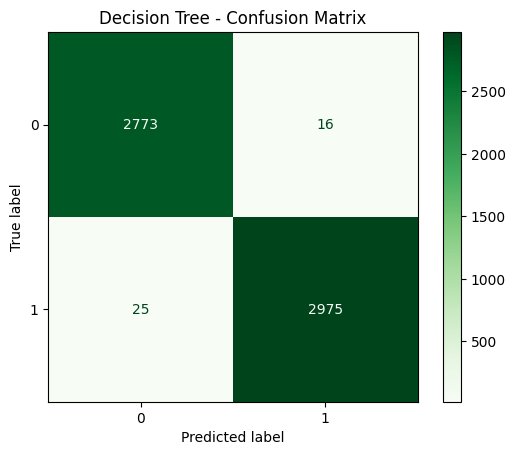

In [26]:
cm = confusion_matrix(y_test_top10, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

**2- XGBoost**

In [27]:
model_xg = XGBClassifier(random_state=42)
model_xg.fit(X_train_top10, y_train_top10)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
y_pred_xg = model_xg.predict(X_test_top10)

In [29]:
correct = 0

for actual, predicted in zip(y_test_top10, y_pred_xg):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5763


In [30]:
accuracy = accuracy_score(y_test_top10, y_pred_xg)
precision = precision_score(y_test_top10, y_pred_xg, average='macro')
recall = recall_score(y_test_top10, y_pred_xg, average='macro')
f1 = f1_score(y_test_top10, y_pred_xg, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9955
Precision: 0.9954
Recall: 0.9956
F1-score: 0.9955


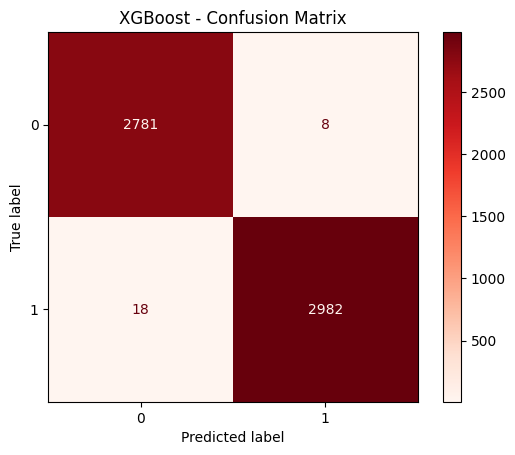

In [31]:
cm = confusion_matrix(y_test_top10, y_pred_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.show()

**3- Random Forest**

In [32]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit (X_train_top10, y_train_top10)

RandomForestClassifier(random_state=42)

In [33]:
y_pred_rf = model_rf.predict(X_test_top10)

In [34]:
correct = 0

for actual, predicted in zip(y_test_top10, y_pred_rf):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5760


In [35]:
accuracy = accuracy_score(y_test_top10, y_pred_rf)
precision = precision_score(y_test_top10, y_pred_rf, average='macro')
recall = recall_score(y_test_top10, y_pred_rf, average='macro')
f1 = f1_score(y_test_top10, y_pred_rf, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9950
Precision: 0.9949
Recall: 0.9951
F1-score: 0.9950


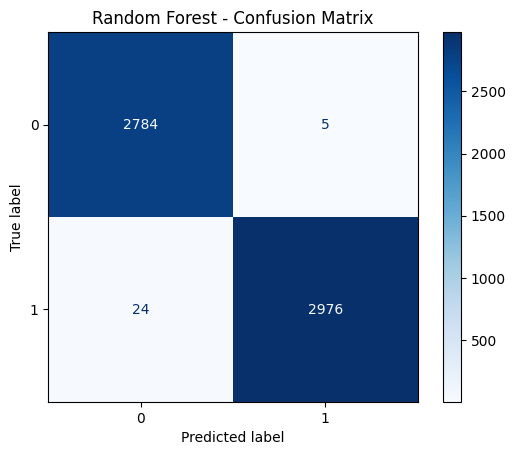

In [36]:
cm = confusion_matrix(y_test_top10, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Unified Featuers

In [37]:
source_file[
    ["name_obfuscations", "entropy_of_streams"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
name_obfuscations,19296.0,0.630338,8.343265,0.0,0.0,0.000000,0.000000,571.000000
entropy_of_streams,19296.0,3.597990,2.942377,0.0,0.0,5.317352,6.131907,7.177038


In [38]:
source_file[["object_count", "stream_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
object_count,19296.0,270.254042,5074.942888,0.0,0.0,20.0,70.0,200006.0
stream_count,19296.0,33.240309,116.071443,0.0,0.0,6.0,32.0,7952.0


In [39]:
# New data frame
unified_df = pd.DataFrame()

unified_df["label"]=source_file["label"]
unified_df["file_size"]=np.log1p(source_file["file_size"])
unified_df["text_size"]=np.log1p(source_file["text_length"])
unified_df["embedded_objects"]=(   #No need for scaling
    source_file["font_object_count"]
    +source_file["image_count"]
    +source_file["acroform_count"])

unified_df["obfuscation_score"]=(
    np.log1p(source_file["name_obfuscations"])# Log transformation to reduce the effect of outliers
 +source_file["entropy_of_streams"]
    )
unified_df["structure_complexity_score"]=(
     np.log1p(source_file["object_count"])# Log transformation to reduce the effect of outliers
    + np.log1p(source_file["stream_count"])
    )
active_cols = [
    "js_count",
    "javascript_count",
    "action_count",
    "aa_count",
    "openaction_count",
    "launch_count",
    "acroform_count",
    "xfa_count",
    "richmedia_count"
]

unified_df["Active_content_score"] = source_file[active_cols].sum(axis=1)
unified_df["Active_content_density"] = (
    unified_df["Active_content_score"] /
    (source_file["file_size"] + 1)
)
unified_df["External_reference_count"] = source_file["uri_count"]




unified_df.describe().T

,count,mean,std,min,25%,50%,75%,max
label,19296.0,0.518190,0.499682,0.000000,0.000000,1.000000,1.000000,1.000000
file_size,19296.0,10.194343,1.273216,3.218876,9.171703,9.767840,11.262892,17.420401
text_size,19296.0,4.812261,4.361636,0.000000,0.000000,7.086738,8.747273,15.043789
embedded_objects,19296.0,3.707400,12.166347,0.000000,0.000000,1.000000,5.000000,796.000000
obfuscation_score,19296.0,3.784959,3.121149,0.000000,0.000000,5.369985,6.474700,13.351214
structure_complexity_score,19296.0,4.548898,4.132347,0.000000,0.000000,4.700480,7.745003,18.385566
Active_content_score,19296.0,1.259069,9.623274,0.000000,0.000000,0.000000,1.000000,1017.000000
Active_content_density,19296.0,0.000062,0.000236,0.000000,0.000000,0.000000,0.000011,0.008026
External_reference_count,19296.0,1.388112,43.492334,0.000000,0.000000,0.000000,0.000000,5682.000000


In [40]:
# All needed imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt



In [41]:
# Original File with All featuers
source_path="/content/PDF_All_features.csv"
source_file=pd.read_csv(source_path)
source_file.head()

,file_path,file_size,title_chars,encrypted,metadata_size,page_count,valid_pdf_header,image_count,text_length,object_count,...,acroform_count,xfa_count,jbig2decode_count,colors_count,richmedia_count,trailer_count,startxref_count,has_multiple_behavioral_keywords_in_one_object,used_ocr,label
0,/content/drive/MyDrive/UNB/Mastercard project/...,20362,8,0,254,5,1,0,8018,120,...,0,0,0,0,0,0,0,0,0,0
1,/content/drive/MyDrive/UNB/Mastercard project/...,28848,35,0,242,4,1,0,11568,36,...,0,0,0,0,0,0,0,0,0,0
2,/content/drive/MyDrive/UNB/Mastercard project/...,76563,12,0,138,1,1,1,1377,21,...,0,0,0,0,0,0,0,0,1,0
3,/content/drive/MyDrive/UNB/Mastercard project/...,67982,8,0,278,4,1,0,30607,46,...,1,0,0,0,0,0,0,0,0,0
4,/content/drive/MyDrive/UNB/Mastercard project/...,3997,37,0,156,1,1,0,1,10,...,0,0,0,0,0,0,0,1,1,1


In [42]:
# Columns names
print(source_file.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['file_path', 'file_size', 'title_chars', 'encrypted', 'metadata_size',
       'page_count', 'valid_pdf_header', 'image_count', 'text_length',
       'object_count', 'font_object_count', 'embedded_file_count',
       'average_embedded_file_size', 'stream_count', 'endstream_count',
       'average_stream_size', 'entropy_of_streams', 'xref_count',
       'xref_entries', 'name_obfuscations', 'total_filters',
       'nested_filter_objects', 'objstm_count', 'js_count', 'javascript_count',
       'uri_count', 'uses_nonstandard_port', 'action_count', 'aa_count',
       'openaction_count', 'launch_count', 'submitform_count',
       'acroform_count', 'xfa_count', 'jbig2decode_count', 'colors_count',
       'richmedia_count', 'trailer_count', 'startxref_count',
       'has_multiple_behavioral_keywords_in_one_object', 'used_ocr', 'label'],
      dtype='object')>


In [43]:
# Find all zero columns

zero_columns=source_file.columns[(source_file==0).all()]
print(zero_columns)

Index(['embedded_file_count', 'average_embedded_file_size', 'xref_count',
       'xref_entries', 'submitform_count', 'jbig2decode_count',
       'trailer_count', 'startxref_count'],
      dtype='object')


In [44]:
# Deleting zero columns

source_file=source_file.drop(columns=zero_columns)

In [45]:
source_file.describe().T

,count,mean,std,min,25%,50%,75%,max
file_size,19296.0,71308.369818,418699.216515,24.0,9620.0,17462.000000,77876.500000,3.677767e+07
title_chars,19296.0,14.792548,19.411976,0.0,0.0,8.000000,25.000000,2.890000e+02
encrypted,19296.0,0.004353,0.065837,0.0,0.0,0.000000,0.000000,1.000000e+00
metadata_size,19296.0,150.339138,149.862796,0.0,0.0,137.000000,251.000000,2.560000e+03
page_count,19296.0,3.232017,9.918278,0.0,0.0,1.000000,2.000000,5.120000e+02
valid_pdf_header,19296.0,0.611578,0.487404,0.0,0.0,1.000000,1.000000,1.000000e+00
image_count,19296.0,1.389096,9.600749,0.0,0.0,0.000000,0.000000,5.920000e+02
text_length,19296.0,8761.265133,37921.556310,0.0,0.0,1195.000000,6292.500000,3.415343e+06
object_count,19296.0,270.254042,5074.942888,0.0,0.0,20.000000,70.000000,2.000060e+05
font_object_count,19296.0,2.025601,6.618683,0.0,0.0,0.000000,3.000000,7.940000e+02


In [46]:
# Number of unique values for each featuer

source_file.nunique()

,0
file_path,19296
file_size,13729
title_chars,135
encrypted,2
metadata_size,562
page_count,108
valid_pdf_header,2
image_count,104
text_length,6610
object_count,1342


In [47]:
# Search for Null Values

null_counts = source_file.groupby("label").apply(lambda x: x.isnull().sum())
print(null_counts)

       file_path  file_size  title_chars  encrypted  metadata_size  \
label                                                                
0              0          0            0          0              0   
1              0          0            0          0              0   

       page_count  valid_pdf_header  image_count  text_length  object_count  \
label                                                                         
0               0                 0            0            0             0   
1               0                 0            0            0             0   

       ...  aa_count  openaction_count  launch_count  acroform_count  \
label  ...                                                             
0      ...         0                 0             0               0   
1      ...         0                 0             0               0   

       xfa_count  colors_count  richmedia_count  \
label                                             
0          

/tmp/ipykernel_708/2367211369.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_counts = source_file.groupby("label").apply(lambda x: x.isnull().sum())


As we can see
There is NO Null values!

In [48]:
# Measure the distribution of ZEROES

(source_file == 0).groupby(source_file["label"]).sum()

,file_path,file_size,title_chars,encrypted,metadata_size,page_count,valid_pdf_header,image_count,text_length,object_count,...,aa_count,openaction_count,launch_count,acroform_count,xfa_count,colors_count,richmedia_count,has_multiple_behavioral_keywords_in_one_object,used_ocr,label
label,,,,,,,,,,,,,,,,,,,,,
0,0,0,19,9220,19,10,11,5561,11,11,...,8773,8617,9284,6527,9295,8659,9297,8988,7042,9297
1,0,0,7665,9992,7665,7445,7484,9836,7488,7484,...,9901,9008,9930,8559,9107,9993,9993,8436,8840,0


In [49]:
# Measure the PERCENT OF ZEROES for each label

zero_percent = (
    source_file.groupby("label")
          .apply(lambda x: (x == 0).mean() * 100)
          .round(2)
          .T
)

print(zero_percent)

label                                                0      1
file_path                                         0.00   0.00
file_size                                         0.00   0.00
title_chars                                       0.20  76.66
encrypted                                        99.17  99.93
metadata_size                                     0.20  76.66
page_count                                        0.11  74.46
valid_pdf_header                                  0.12  74.85
image_count                                      59.81  98.37
text_length                                       0.12  74.89
object_count                                      0.12  74.85
font_object_count                                24.36  93.24
stream_count                                      0.12  74.90
endstream_count                                   0.12  74.90
average_stream_size                               0.12  74.90
entropy_of_streams                                0.12  75.12
name_obf

/tmp/ipykernel_708/1014244302.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x == 0).mean() * 100)


In [50]:
# BINARY COLUMNS

binary_columns = source_file.columns[source_file.nunique() == 2]
print(binary_columns)

Index(['encrypted', 'valid_pdf_header', 'uses_nonstandard_port', 'used_ocr',
       'label'],
      dtype='object')


In [51]:
source_file[
    (source_file["object_count"] == 0) &
    (source_file["stream_count"] == 0)
][["file_path", "label"]].head(20)

,file_path,label
8,/content/drive/MyDrive/UNB/Mastercard project/...,1
9,/content/drive/MyDrive/UNB/Mastercard project/...,1
11,/content/drive/MyDrive/UNB/Mastercard project/...,1
12,/content/drive/MyDrive/UNB/Mastercard project/...,1
18,/content/drive/MyDrive/UNB/Mastercard project/...,1
20,/content/drive/MyDrive/UNB/Mastercard project/...,1
24,/content/drive/MyDrive/UNB/Mastercard project/...,1
31,/content/drive/MyDrive/UNB/Mastercard project/...,1
32,/content/drive/MyDrive/UNB/Mastercard project/...,1
35,/content/drive/MyDrive/UNB/Mastercard project/...,1


In [52]:
mask = (
    (source_file["object_count"] == 0) &
    (source_file["stream_count"] == 0) &
    (source_file["endstream_count"] == 0) &
    (source_file["entropy_of_streams"] == 0)
)

print(mask.sum())
print(mask.mean() * 100)
pd.crosstab(source_file["label"], mask)

7495
38.842247097844115


col_0,False,True
label,,
0,9286,11
1,2515,7484


In [53]:
feature_cols = source_file.columns.drop(['file_path', 'label'])

dupe_count = source_file.duplicated(subset=feature_cols).sum()
print(f"Exact duplicate feature rows: {dupe_count}")

dupe_rows = source_file[source_file.duplicated(subset=feature_cols, keep=False)]
print(dupe_rows['label'].value_counts())

Exact duplicate feature rows: 3943
label
1    5675
0      28
Name: count, dtype: int64


In [54]:
clean_pdf = source_file.drop_duplicates(subset=feature_cols, keep='first')
print("Before:", source_file.shape)
print("After:", clean_pdf.shape)
print(clean_pdf['label'].value_counts())

Before: (19296, 34)
After: (15353, 34)
label
0    9283
1    6070
Name: count, dtype: int64


# Reproduce after deleting zero columns


In [55]:
top10="/content/PDF_Top10_features.csv"
top10_file=pd.read_csv(top10)

suspicious_features = [
    "object_count",
    "stream_count",
    "endstream_count",
    "valid_pdf_header",
    "entropy_of_streams"
]

top10_file_filtered = top10_file.drop(columns=suspicious_features)

top10_file_filtered.head()

,text_length,total_filters,title_chars,file_size,metadata_size,label
0,8018,8,8,20362,254,0
1,11568,7,35,28848,242,0
2,1377,2,12,76563,138,0
3,30607,11,8,67982,278,0
4,1,2,37,3997,156,1


In [56]:
X = top10_file_filtered.drop(columns=["label"])
y = top10_file_filtered["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

1- Decision Tree

In [57]:
model_dt = DecisionTreeClassifier (random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [58]:
y_pred_dt = model_dt.predict(X_test)

correct = 0

for actual, predicted in zip(y_test, y_pred_dt):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5748


In [59]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='macro')
recall = recall_score(y_test, y_pred_dt, average='macro')
f1 = f1_score(y_test, y_pred_dt, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9929
Precision: 0.9929
Recall: 0.9930
F1-score: 0.9929


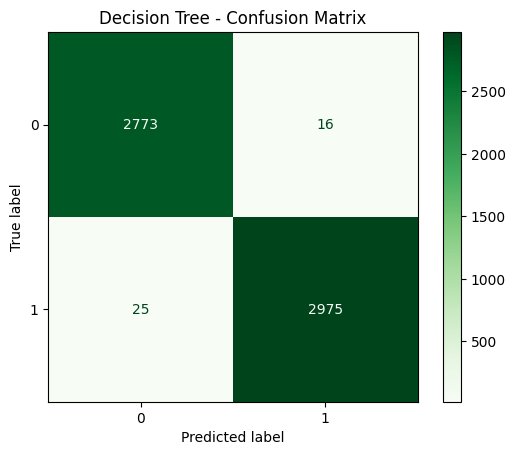

In [60]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

**2- XGBoost**

In [61]:
model_xg = XGBClassifier(random_state=42)
model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [62]:
y_pred_xg = model_xg.predict(X_test)

In [63]:
correct = 0

for actual, predicted in zip(y_test, y_pred_xg):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5763


In [64]:
accuracy = accuracy_score(y_test, y_pred_xg)
precision = precision_score(y_test, y_pred_xg, average='macro')
recall = recall_score(y_test, y_pred_xg, average='macro')
f1 = f1_score(y_test, y_pred_xg, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9955
Precision: 0.9954
Recall: 0.9956
F1-score: 0.9955


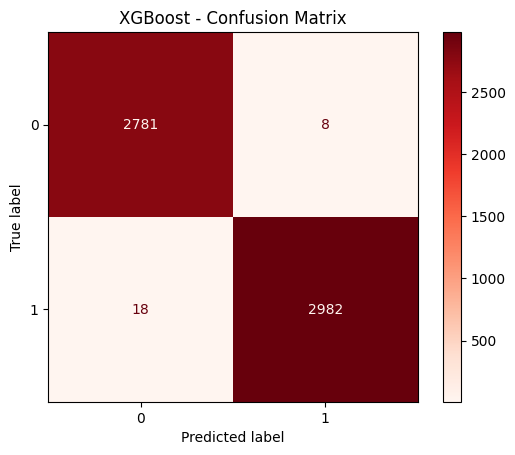

In [65]:
cm = confusion_matrix(y_test, y_pred_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.show()

**3- Random Forest**

In [66]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit (X_train, y_train)

RandomForestClassifier(random_state=42)

In [67]:
y_pred_rf = model_rf.predict(X_test)

In [68]:
correct = 0

for actual, predicted in zip(y_test, y_pred_rf):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5760


In [69]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='macro')
recall = recall_score(y_test, y_pred_rf, average='macro')
f1 = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9950
Precision: 0.9949
Recall: 0.9951
F1-score: 0.9950


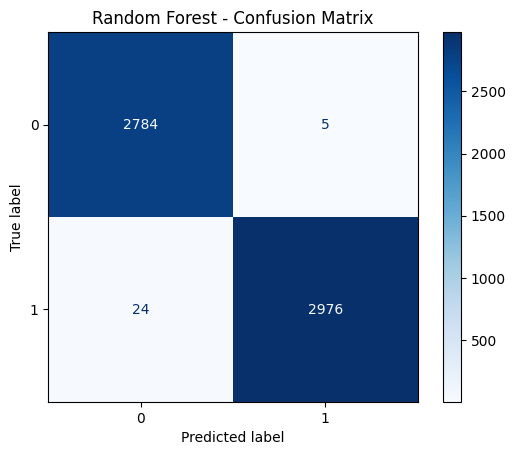

In [70]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Unified Featuers

In [71]:
clean_pdf.describe().T

,count,mean,std,min,25%,50%,75%,max
file_size,15353.0,85496.965349,465620.490344,24.0,14961.00000,31987.000000,87455.000000,3.677767e+07
title_chars,15353.0,18.367094,20.128187,0.0,0.00000,12.000000,29.000000,2.890000e+02
encrypted,15353.0,0.005471,0.073768,0.0,0.00000,0.000000,0.000000,1.000000e+00
metadata_size,15353.0,186.083762,146.284544,0.0,0.00000,194.000000,282.000000,2.560000e+03
page_count,15353.0,4.025207,10.941615,0.0,1.00000,1.000000,4.000000,5.120000e+02
valid_pdf_header,15353.0,0.752361,0.431655,0.0,1.00000,1.000000,1.000000,1.000000e+00
image_count,15353.0,1.744480,10.733825,0.0,0.00000,0.000000,1.000000,5.920000e+02
text_length,15353.0,10903.985280,42175.061078,0.0,1.00000,1559.000000,9239.000000,3.415343e+06
object_count,15353.0,325.897154,5454.304448,0.0,7.00000,24.000000,114.000000,2.000060e+05
font_object_count,15353.0,2.526933,7.332430,0.0,0.00000,0.000000,4.000000,7.940000e+02


In [72]:
clean_pdf[
    ["name_obfuscations", "entropy_of_streams"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
name_obfuscations,15353.0,0.787338,9.342774,0.0,0.00000,0.000000,0.000000,571.000000
entropy_of_streams,15353.0,4.428231,2.637776,0.0,2.32383,5.564434,6.368294,7.177038


In [73]:
clean_pdf[["object_count", "stream_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
object_count,15353.0,325.897154,5454.304448,0.0,7.0,24.0,114.0,200006.0
stream_count,15353.0,41.546278,128.758669,0.0,2.0,16.0,44.0,7952.0


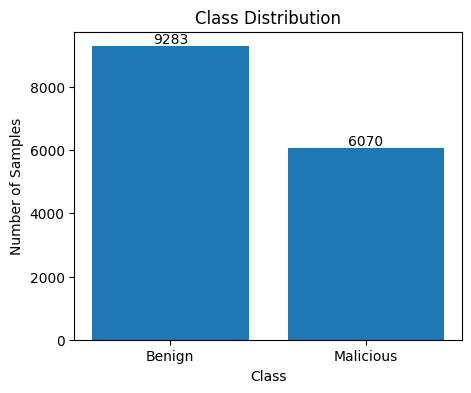

In [74]:
class_counts = clean_pdf["label"].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(["Benign", "Malicious"], class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

for i, v in enumerate(class_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.show()

In [75]:
# New data frame
unified_df = pd.DataFrame()
unified_df["file_size"]=np.log1p(clean_pdf["file_size"])
unified_df["text_size"]=np.log1p(clean_pdf["text_length"])
unified_df["embedded_objects"]=np.log1p(#Log transformation to reduce the effect of outliers
    clean_pdf["font_object_count"] +
    clean_pdf["image_count"] +
    clean_pdf["acroform_count"]
)
active_cols = [
    "js_count",
    "javascript_count",
    "action_count",
    "aa_count",
    "openaction_count",
    "launch_count",
    "acroform_count",
    "xfa_count",
    "richmedia_count"
]
unified_df["active_content_score"] = clean_pdf[active_cols].sum(axis=1)
unified_df["active_content_density"] = (
    unified_df["active_content_score"] /
    (clean_pdf["file_size"] + 1)
)
unified_df["external_reference_count"] = clean_pdf["uri_count"]
unified_df["obfuscation_score"]=(
    np.log1p(clean_pdf["name_obfuscations"])# Log transformation to reduce the effect of outliers
 +clean_pdf["entropy_of_streams"]
    )
unified_df["structural_complexity_score"]=(
     np.log1p(clean_pdf["object_count"])# Log transformation to reduce the effect of outliers
    + np.log1p(clean_pdf["stream_count"])
    )

unified_df["label"]=clean_pdf["label"]



unified_df.describe().T

,count,mean,std,min,25%,50%,75%,max
file_size,15353.0,10.472696,1.244857,3.218876,9.613269,10.373116,11.378891,17.420401
text_size,15353.0,5.936672,4.106461,0.000000,0.693147,7.352441,9.131297,15.043789
embedded_objects,15353.0,1.138210,0.987759,0.000000,0.000000,0.693147,1.945910,6.680855
active_content_score,15353.0,1.525174,10.760117,0.000000,0.000000,0.000000,2.000000,1017.000000
active_content_density,15353.0,0.000072,0.000257,0.000000,0.000000,0.000000,0.000016,0.008026
external_reference_count,15353.0,1.743568,48.752357,0.000000,0.000000,0.000000,0.000000,5682.000000
obfuscation_score,15353.0,4.661735,2.812937,0.000000,2.681403,5.833876,6.600520,13.351214
structural_complexity_score,15353.0,5.635139,3.904532,0.000000,3.178054,5.988961,8.567126,18.385566
label,15353.0,0.395362,0.488944,0.000000,0.000000,0.000000,1.000000,1.000000


In [76]:
corr = unified_df["text_size"].corr(unified_df["label"])
print(corr)

-0.8184702158853092


# ML on the unified featuers

In [77]:
X = unified_df.drop(columns=['label'])
y =  unified_df['label']

X_train, X_test, y_train, y_test = train_test_split (X, y, train_size=0.7, random_state=42, stratify=y)


1- Decision Tree

In [78]:
model_dt = DecisionTreeClassifier (random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [79]:
y_pred_dt = model_dt.predict(X_test)

correct = 0

for actual, predicted in zip(y_test, y_pred_dt):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 4567


In [80]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='macro')
recall = recall_score(y_test, y_pred_dt, average='macro')
f1 = f1_score(y_test, y_pred_dt, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9915
Precision: 0.9908
Recall: 0.9915
F1-score: 0.9912


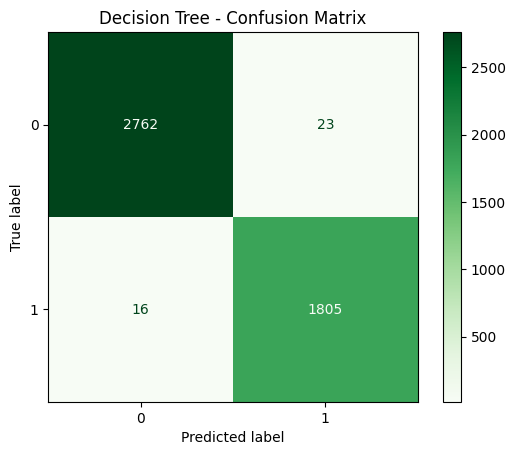

In [81]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

**2- XGBoost**

In [82]:
model_xg = XGBClassifier(random_state=42)
model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [83]:
y_pred_xg = model_xg.predict(X_test)

In [84]:
correct = 0

for actual, predicted in zip(y_test, y_pred_xg):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 4578


In [85]:
accuracy = accuracy_score(y_test, y_pred_xg)
precision = precision_score(y_test, y_pred_xg, average='macro')
recall = recall_score(y_test, y_pred_xg, average='macro')
f1 = f1_score(y_test, y_pred_xg, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9939
Precision: 0.9936
Recall: 0.9936
F1-score: 0.9936


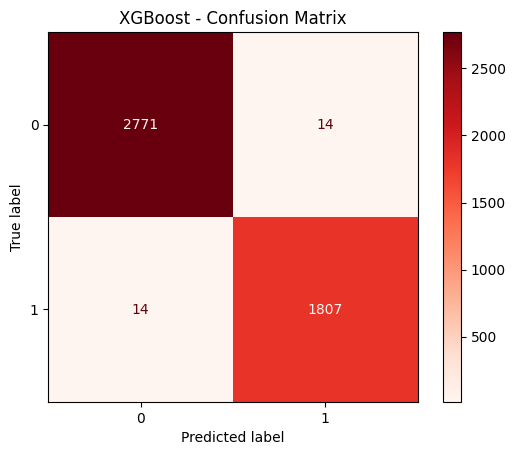

In [86]:
cm = confusion_matrix(y_test, y_pred_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.show()

**3- Random Forest**

In [87]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit (X_train, y_train)

RandomForestClassifier(random_state=42)

In [88]:
y_pred_rf = model_rf.predict(X_test)

In [89]:
correct = 0

for actual, predicted in zip(y_test, y_pred_rf):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 4576


In [90]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='macro')
recall = recall_score(y_test, y_pred_rf, average='macro')
f1 = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9935
Precision: 0.9931
Recall: 0.9933
F1-score: 0.9932


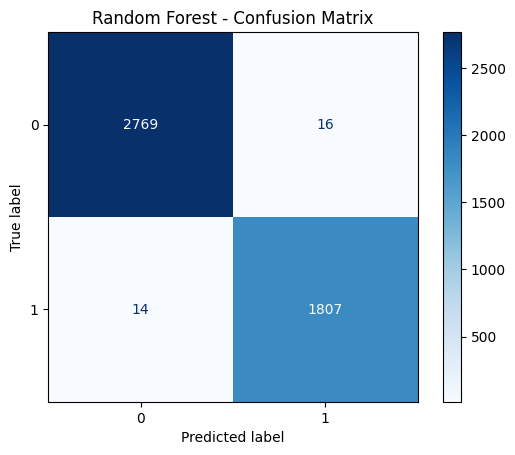

In [91]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

**Featuers Importance**

In [92]:
print("Individual Unified Feature Performance:\n")

results = {}

for col in X_train.columns:

    tree = DecisionTreeClassifier(random_state=42)

    tree.fit(X_train[[col]], y_train)

    pred = tree.predict(X_test[[col]])

    results[col] = accuracy_score(y_test, pred)

for feature, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature:<30} {acc:.4f}")

Individual Unified Feature Performance:

structural_complexity_score    0.9739
text_size                      0.9627
obfuscation_score              0.8927
embedded_objects               0.8762
file_size                      0.8723
active_content_density         0.7286
active_content_score           0.6689
external_reference_count       0.6046


In [93]:
# Downloading CSV
unified_df.to_csv("/content/PDF_unified_features.csv", index=False)

In [94]:
from google.colab import files
files.download("/content/PDF_unified_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [95]:
X_unified = unified_df.drop(columns=['label'])

y_unified = unified_df['label']

X_train_unified, X_test_unified, y_train_unified, y_test_unified = train_test_split(
    X_unified, y_unified,
    test_size=0.3,
    random_state=42,
    stratify=y_unified
)

Experiment

In [125]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Models
models = {
    "Logistic L1": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=1.0,
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=25,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=25,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )
}

# Three feature sets
datasets = {
    "All Features": (X_train_all, X_test_all, y_train_all, y_test_all),
    "Top 10": (X_train_top10, X_test_top10, y_train_top10, y_test_top10),
    "Unified": (X_train_unified, X_test_unified, y_train_unified, y_test_unified),
    "Raw": (X_train_raw, X_test_raw, y_train_raw, y_test_raw)
}

from sklearn.base import clone
results = []
fitted_models = {}

for feature_set, (X_train, X_test, y_train, y_test) in datasets.items():

    for model_name, model in models.items():

        model = clone(model)
        model.fit(X_train, y_train)
        fitted_models[(feature_set, model_name)] = model

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "Feature Set": feature_set,
            "Model": model_name,
            "no. features": X_train.shape[1],
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

# Final table
results_df = pd.DataFrame(results)

display(results_df.round(4))

,Feature Set,Model,no. features,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,All Features,Logistic L1,32,0.9941,0.9956,0.9896,0.9926,0.9954
1,All Features,Random Forest,32,0.9970,0.9972,0.9951,0.9962,0.9997
2,All Features,XGBoost,32,0.9965,0.9962,0.9951,0.9956,0.9997
3,Top 10,Logistic L1,5,0.9135,0.8945,0.9443,0.9188,0.9661
4,Top 10,Random Forest,5,0.9952,0.9983,0.9923,0.9953,0.9995
5,Top 10,XGBoost,5,0.9898,0.9953,0.9850,0.9901,0.9979
6,Unified,Logistic L1,8,0.9800,0.9822,0.9671,0.9745,0.9923
7,Unified,Random Forest,8,0.9931,0.9901,0.9923,0.9912,0.9987
8,Unified,XGBoost,8,0.9902,0.9895,0.9857,0.9876,0.9982
9,Raw,Logistic L1,40,0.9934,0.9976,0.9897,0.9936,0.9969


In [127]:
print("coef length:", len(coef))
print("source_file.columns length:", len(X_train_raw.columns))

coef length: 40
source_file.columns length: 40


In [124]:
for name, (Xtr, Xte, ytr, yte) in datasets.items():
    print(name, Xtr.shape)


Raw (13507, 40)
All Features (10747, 32)
Top 10 (13507, 5)
Unified (10747, 8)


In [128]:
# L1/LASSO selected features from leakage-reduced raw data
lasso_model = fitted_models[("Raw", "Logistic L1")]
coef = lasso_model.named_steps["model"].coef_[0]

lasso_features = pd.DataFrame({
    "feature": X_train_raw.columns,   # assumes X_train_raw is a DataFrame with column names — see note below
    "coefficient": coef,
    "absolute_coefficient": np.abs(coef)
}).sort_values("absolute_coefficient", ascending=False)

selected_lasso_features = lasso_features.loc[
    lasso_features["absolute_coefficient"] > 1e-8, "feature"
].tolist()

display(lasso_features)
print("Selected by L1:", len(selected_lasso_features))
print(selected_lasso_features)
lasso_features.to_csv("lasso_feature_ranking.csv", index=False)

,feature,coefficient,absolute_coefficient
22,js_count,-17.070876,17.070876
23,javascript_count,16.480301,16.480301
27,aa_count,-7.851469,7.851469
38,has_multiple_behavioral_keywords_in_one_object,4.168621,4.168621
3,metadata_size,-2.660311,2.660311
13,endstream_count,-2.411539,2.411539
5,valid_pdf_header,-2.149961,2.149961
32,xfa_count,2.123103,2.123103
34,colors_count,-2.063463,2.063463
9,font_object_count,-1.982912,1.982912


Selected by L1: 29
['js_count', 'javascript_count', 'aa_count', 'has_multiple_behavioral_keywords_in_one_object', 'metadata_size', 'endstream_count', 'valid_pdf_header', 'xfa_count', 'colors_count', 'font_object_count', 'entropy_of_streams', 'nested_filter_objects', 'objstm_count', 'openaction_count', 'title_chars', 'encrypted', 'used_ocr', 'acroform_count', 'launch_count', 'action_count', 'file_size', 'uses_nonstandard_port', 'total_filters', 'object_count', 'average_stream_size', 'page_count', 'image_count', 'richmedia_count', 'name_obfuscations']


In [130]:
# Evaluate LASSO-selected raw feature subset
if selected_lasso_features:

    for model_name, model in models.items():

        model = clone(model)   # fresh unfitted copy — same fix as the main loop
        model.fit(X_train_raw[selected_lasso_features], y_train_raw)

        y_pred = model.predict(X_test_raw[selected_lasso_features])
        y_prob = model.predict_proba(X_test_raw[selected_lasso_features])[:, 1]

        fitted_models[("LASSO Selected", model_name)] = model   # keep it reusable, same as the main loop

        results.append({
            "Feature Set": "LASSO Selected",
            "Model": model_name,
            "no. features": len(selected_lasso_features),
            "Accuracy": accuracy_score(y_test_raw, y_pred),
            "Precision": precision_score(y_test_raw, y_pred, zero_division=0),
            "Recall": recall_score(y_test_raw, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test_raw, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test_raw, y_prob)
        })

    results_df = pd.DataFrame(results).round(4)
    display(results_df[results_df["Feature Set"] == "LASSO Selected"])

    results_df.to_csv("model_comparison_results.csv", index=False)

,Feature Set,Model,no. features,Accuracy,Precision,Recall,F1 Score,ROC-AUC
12,LASSO Selected,Logistic L1,29,0.9934,0.9976,0.9897,0.9936,0.9968
13,LASSO Selected,Random Forest,29,0.9969,0.9980,0.9960,0.9970,0.9998
14,LASSO Selected,XGBoost,29,0.9959,0.9980,0.9940,0.9960,0.9984
